In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns  
from matplotlib import pyplot as plt 
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame({
    'x1' : [1,2,3,4,5,6,6,7,9,9], 
    'x2' : [5,3,6,8,1,9,5,8,9,2], 
    'label' : [1,1,0,1,0,1,0,1,0,0]
})

In [3]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


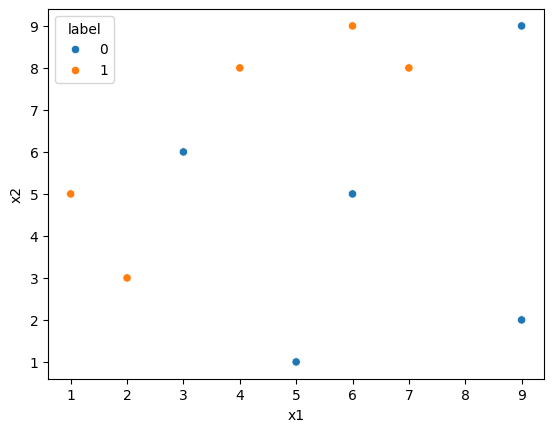

In [4]:
sns.scatterplot(x = df['x1'] , y = df['x2'] , hue = df['label'])
plt.show()

In [5]:
# add initial weights to all rows 
df['weights'] = 1 / df.shape[0]
df

,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [6]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [7]:
y.shape

(10,)

In [8]:
# Use a decision tree with max_depth = 1 
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth = 1)

In [9]:
# train the 1st tree 
dt1.fit(X , y)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


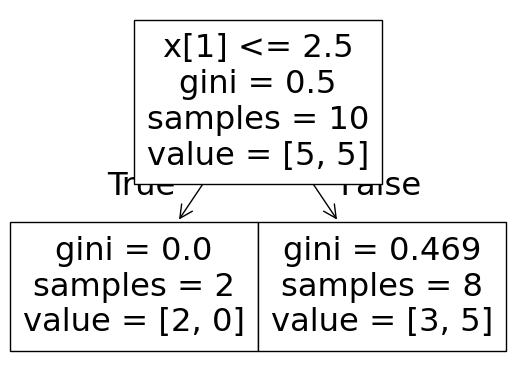

In [10]:
from sklearn.tree import plot_tree
plot_tree(dt1) 
plt.show()

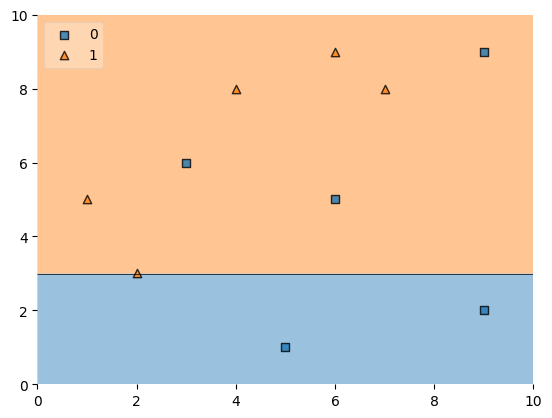

In [12]:
plot_decision_regions(X , y , clf = dt1 , legend = 2)
plt.show()

In [13]:
df['predict'] = dt1.predict(X)

In [14]:
df

,x1,x2,label,weights,predict
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [17]:
# calculate model weights from model error
def calculate_model_weight(error): 
    return 0.5 * np.log((1 - error) / error)

In [18]:
# step-3: calculate model weights
alpha1 = calculate_model_weight(error = 0.3) # cause 3 class misclassified
alpha1

np.float64(0.42364893019360184)

In [19]:
# step-4: update model-1 weights for all rows 
def update_row_weights(row , alpha = 0.4236): 
    # this take a single row and if correct classified then increate weight else decrease 
    if row['label'] == row['predict']: 
        return row['weights'] * np.exp(-alpha) 
    else:
        return row['weights'] * np.exp(alpha)

In [20]:
df['updated_weights'] = df.apply(update_row_weights , axis = 1)

In [21]:
df

,x1,x2,label,weights,predict,updated_weights
0,1,5,1,0.1,1,0.065469
1,2,3,1,0.1,1,0.065469
2,3,6,0,0.1,1,0.152745
3,4,8,1,0.1,1,0.065469
4,5,1,0,0.1,0,0.065469
5,6,9,1,0.1,1,0.065469
6,6,5,0,0.1,1,0.152745
7,7,8,1,0.1,1,0.065469
8,9,9,0,0.1,1,0.152745
9,9,2,0,0.1,0,0.065469
